# MILESTONE M2 — NHIỆM VỤ 4: PHƯƠNG ÁN A — K-MEANS BASELINE

Notebook này thực hiện toàn diện quy trình **Nhiệm vụ 4: Phân cụm K-Means Baseline** theo tài liệu `Ke_hoach_M2_Phan_cum_co_phieu.md` và cấu hình thực nghiệm đã khóa `configs/experiments/m2_market_only_v1.json`.

---

### Các quy tắc thực nghiệm bắt buộc (Frozen Invariants):
1. **Giai đoạn Development:** 15 snapshot cuối tháng liên tiếp (30/11/2023 đến 24/01/2025).
2. **Universe điều kiện:** Mỗi tháng chỉ lấy các mã có `market_feature_ready_v2 == True` tại chính tháng đó; ngưỡng tối thiểu n_eligible >= 120.
3. **8 đặc trưng thị trường:** `mom_21`, `mom_63`, `mom_126`, `mom_252`, `vol_63`, `mdd_126`, `beta_126`, `liquidity_21`.
4. **Chuẩn hóa (Robust Scaling per snapshot):** Tính riêng Median và IQR trên từng snapshot: x' = (x - Median) / IQR. Không dùng chung scaler giữa các tháng.
5. **Số cụm Global K:** Cố định **K = 2** (đã chọn và khóa ở Nhiệm vụ 3, seed = 42, n_init = 10, max_iter = 300).
6. **Đường dẫn Output chuẩn hóa:**
   - Mô hình fitted: `M2/models/kmeans/{snapshot_date}.json`
   - Artifacts thực nghiệm: `M2/artifacts/m2-task4-kmeans-baseline-v1/` (`assignments.jsonl`, `profiles.jsonl`, `diagnostics.jsonl`, `manifest.json`)
7. **Không rò rỉ dữ liệu:** Không dùng tương lai, không mở holdout, không dùng Sharpe/lợi nhuận để chọn hoặc chỉnh cụm.


In [1]:
import os
import sys
import json
import time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cấu hình matplotlib hiển thị rõ ràng, font sạch
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Xác định thư mục gốc của dự án (ROOT)
current_dir = Path.cwd().resolve()
if (current_dir / "configs/experiments/m2_market_only_v1.json").exists():
    ROOT = current_dir
elif (current_dir.parent / "configs/experiments/m2_market_only_v1.json").exists():
    ROOT = current_dir.parent
elif (current_dir.parent.parent / "configs/experiments/m2_market_only_v1.json").exists():
    ROOT = current_dir.parent.parent
else:
    ROOT = Path("d:/Risk-Adjusted-Momentum-Clustering")

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Nạp cấu hình chính thức m2_market_only_v1.json
CONFIG_PATH = ROOT / "configs/experiments/m2_market_only_v1.json"
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

DEV_SNAPSHOTS = config["development_snapshots"]
FEATURES = config["clustering"]["features"]
GLOBAL_K = config["clustering"]["k"]
MIN_ELIGIBLE = config["min_eligible_count"]

# Định nghĩa đường dẫn dữ liệu và output theo đúng quy ước kế hoạch M2
DATA_RUN = ROOT / "artifacts/cafef_primary/cafef-c8-complete-only-v1"
M2_MODELS_DIR = ROOT / "M2/models/kmeans"
M2_ARTIFACTS_DIR = ROOT / "M2/artifacts/m2-task4-kmeans-baseline-v1"

M2_MODELS_DIR.mkdir(parents=True, exist_ok=True)
M2_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"[OK] Root path: {ROOT}")
print(f"[OK] Protocol: {config.get('protocol_scope')} (Stage: {config.get('stage')})")
print(f"[OK] Global K đã khóa: K = {GLOBAL_K}")
print(f"[OK] Số snapshot development: {len(DEV_SNAPSHOTS)} tháng ({DEV_SNAPSHOTS[0]} -> {DEV_SNAPSHOTS[-1]})")
print(f"[OK] 8 đặc trưng thị trường: {FEATURES}")
print(f"[OK] Ngưỡng cổ phiếu tối thiểu mỗi tháng: {MIN_ELIGIBLE} mã")
print(f"[OK] Thư mục output models: {M2_MODELS_DIR}")
print(f"[OK] Thư mục output artifacts: {M2_ARTIFACTS_DIR}")


[OK] Root path: D:\Risk-Adjusted-Momentum-Clustering
[OK] Protocol: m2_market_only_v1 (Stage: M2_TASK_3_GLOBAL_K_FROZEN)
[OK] Global K đã khóa: K = 2
[OK] Số snapshot development: 15 tháng (2023-11-30 -> 2025-01-24)
[OK] 8 đặc trưng thị trường: ['mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_63', 'mdd_126', 'beta_126', 'liquidity_21']
[OK] Ngưỡng cổ phiếu tối thiểu mỗi tháng: 120 mã
[OK] Thư mục output models: D:\Risk-Adjusted-Momentum-Clustering\M2\models\kmeans
[OK] Thư mục output artifacts: D:\Risk-Adjusted-Momentum-Clustering\M2\artifacts\m2-task4-kmeans-baseline-v1


## 1. Phần 4.1 & 4.2: Dữ Liệu Đầu Vào & Kiểm Tra Điều Kiện Snapshot

Theo quy ước Phần 4.1 và 4.2 của kế hoạch M2:
- Dữ liệu được nạp từ nguồn thị trường chuẩn hóa C8 (`feature_snapshots.jsonl`).
- Mỗi tháng lọc độc lập các mã cổ phiếu đạt điều kiện `market_feature_ready_v2 == True`.
- Kiểm tra tính hợp lệ: Số mã đủ điều kiện phải đạt ngưỡng n_eligible >= 120, đủ 8 feature, không có NaN/Inf.
- Không lấy số lượng mã ở thời điểm cuối (780 hoặc 905 mã) áp ngược lại cho quá khứ.


Đang nạp và kiểm tra dữ liệu 15 snapshot từ nguồn C8 canonical...
[OK] Nạp thành công 15 snapshot trong 2.02s

--- BẢNG KIỂM TRA ĐIỀU KIỆN 15 SNAPSHOT DEVELOPMENT ---


,snapshot,status,eligible_count,meets_min_count
0,2023-11-30,ready,142,True
1,2023-12-29,ready,195,True
2,2024-01-31,ready,196,True
3,2024-02-29,ready,196,True
4,2024-03-29,ready,197,True
5,2024-04-26,ready,214,True
6,2024-05-31,ready,221,True
7,2024-06-28,ready,240,True
8,2024-07-31,ready,247,True
9,2024-08-30,ready,595,True


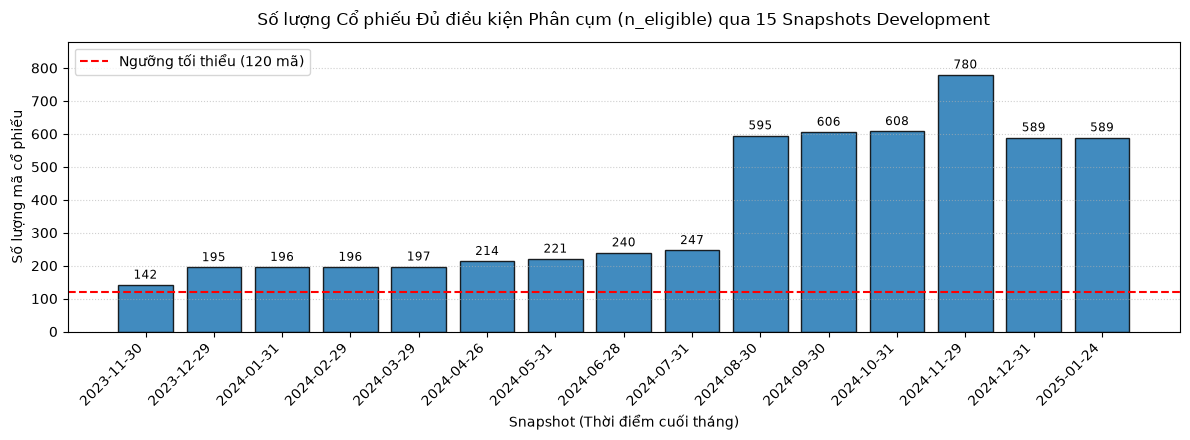

[KẾT QUẢ] Số mã dao động từ 142 mã (2023-11-30) đến 780 mã (2024-11-29).
[CHỨNG MINH] Vũ trụ cổ phiếu thay đổi thực tế theo từng tháng, không bị rò rỉ hay áp đặt số lượng cố định.


In [2]:
from delta_t1.experiments.runner import prepare_m2_market_only_snapshots

print("Đang nạp và kiểm tra dữ liệu 15 snapshot từ nguồn C8 canonical...")
t0 = time.time()
source_meta, prepared_snapshots = prepare_m2_market_only_snapshots(DATA_RUN, config)
print(f"[OK] Nạp thành công {len(prepared_snapshots)} snapshot trong {time.time() - t0:.2f}s")

# Tổng hợp bảng kiểm định (validation table)
val_records = []
for snap in prepared_snapshots:
    val_records.append({
        "snapshot": snap["snapshot_date"],
        "status": snap["status"],
        "eligible_count": snap["eligible_count"],
        "meets_min_count": snap["eligible_count"] >= MIN_ELIGIBLE
    })

df_validation = pd.DataFrame(val_records)
print(f"\n--- BẢNG KIỂM TRA ĐIỀU KIỆN 15 SNAPSHOT DEVELOPMENT ---")
display(df_validation)

assert df_validation["meets_min_count"].all(), "Có snapshot không đạt ngưỡng tối thiểu 120 mã!"
assert len(df_validation) == 15, "Không đủ 15 snapshot development!"

# Vẽ biểu đồ biến thiên số lượng cổ phiếu đủ điều kiện qua 15 tháng
plt.figure(figsize=(12, 4.5))
bars = plt.bar(df_validation["snapshot"], df_validation["eligible_count"], color="#1f77b4", edgecolor="black", alpha=0.85)
plt.axhline(MIN_ELIGIBLE, color="red", linestyle="--", linewidth=1.5, label=f"Ngưỡng tối thiểu ({MIN_ELIGIBLE} mã)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f"{int(yval)}", ha="center", va="bottom", fontsize=8.5)

plt.title("Số lượng Cổ phiếu Đủ điều kiện Phân cụm (n_eligible) qua 15 Snapshots Development", pad=12)
plt.xlabel("Snapshot (Thời điểm cuối tháng)")
plt.ylabel("Số lượng mã cổ phiếu")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(df_validation["eligible_count"]) + 100)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"[KẾT QUẢ] Số mã dao động từ {df_validation['eligible_count'].min()} mã ({df_validation.loc[df_validation['eligible_count'].idxmin(), 'snapshot']}) "
      f"đến {df_validation['eligible_count'].max()} mã ({df_validation.loc[df_validation['eligible_count'].idxmax(), 'snapshot']}).")
print("[CHỨNG MINH] Vũ trụ cổ phiếu thay đổi thực tế theo từng tháng, không bị rò rỉ hay áp đặt số lượng cố định.")


## 2. Phần 4.3: Chuẩn Hóa Robust Scaling Độc Lập Theo Từng Snapshot

Thuật toán K-Means phân cụm dựa trên khoảng cách Euclidean, trong khi 8 đặc trưng có thang đo rất chênh lệch (ví dụ: Thanh khoản hàng trăm tỷ VND vs Động lượng tính bằng %).

Công thức Robust Scaling:
x' = (x - Median) / IQR

Quy tắc bắt buộc:
- Bộ tham số (Median, IQR) được tính riêng độc lập cho từng snapshot.
- Tuyệt đối không dùng chung scaler của tháng này cho tháng khác, không fit chung trên toàn bộ giai đoạn development.


=== THAM SỐ ROBUST SCALER TẠI SNAPSHOT 2023-11-30 ===


,Feature,Median (Center),IQR (Scale),Min,Max
0,mom_21,3.931943e-02,8.677748e-02,-1.181663e-01,3.232826e-01
1,mom_63,-6.283969e-02,1.530779e-01,-3.291139e-01,6.397172e-01
2,mom_126,-8.386447e-03,2.116936e-01,-5.281899e-01,8.642855e-01
3,mom_252,1.284203e-01,3.663696e-01,-3.875363e-01,1.976035e+00
4,vol_63,3.366537e-01,2.047389e-01,8.012943e-02,6.586248e-01
5,mdd_126,-1.973940e-01,1.648245e-01,-6.246575e-01,-1.442216e-02
6,beta_126,5.284183e-01,8.602723e-01,-4.222132e-01,2.103151e+00
7,liquidity_21,1.080500e+09,1.263856e+10,1.380952e+06,3.449138e+11


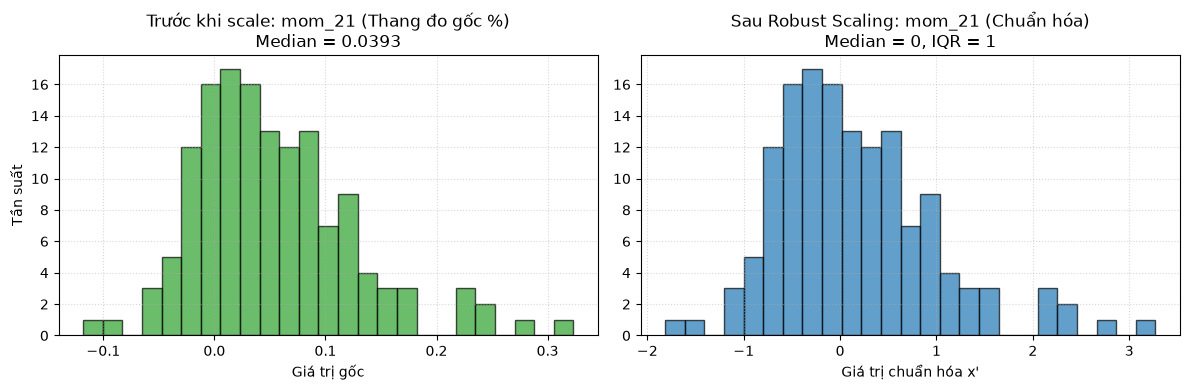

In [3]:
from delta_t1.features.preprocessing import preprocess

# Xem tham số Scaler của snapshot đầu tiên (2023-11-30)
sample_snap = prepared_snapshots[0]
vectors_sample, scaler_sample = preprocess(sample_snap["rows"], config["clustering"])

scaler_records = []
for feat in FEATURES:
    info = scaler_sample[feat]
    scaler_records.append({
        "Feature": feat,
        "Median (Center)": info["center"],
        "IQR (Scale)": info["scale"],
        "Min": info["lower"],
        "Max": info["upper"]
    })

df_scaler = pd.DataFrame(scaler_records)
print(f"=== THAM SỐ ROBUST SCALER TẠI SNAPSHOT {sample_snap['snapshot_date']} ===")
display(df_scaler)

# Vẽ so sánh phân phối trước và sau khi Robust Scaling của một đặc trưng tiêu biểu (mom_21)
raw_mom21 = [r["mom_21"] for r in sample_snap["rows"]]
idx_mom21 = FEATURES.index("mom_21")
scaled_mom21 = [v[idx_mom21] for v in vectors_sample]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(raw_mom21, bins=25, color="#2ca02c", edgecolor="black", alpha=0.7)
ax1.set_title(f"Trước khi scale: mom_21 (Thang đo gốc %)\nMedian = {scaler_sample['mom_21']['center']:.4f}")
ax1.set_xlabel("Giá trị gốc")
ax1.set_ylabel("Tần suất")
ax1.grid(linestyle=":", alpha=0.5)

ax2.hist(scaled_mom21, bins=25, color="#1f77b4", edgecolor="black", alpha=0.7)
ax2.set_title("Sau Robust Scaling: mom_21 (Chuẩn hóa)\nMedian = 0, IQR = 1")
ax2.set_xlabel("Giá trị chuẩn hóa x'")
ax2.grid(linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


## 3. Phần 4.4 & 4.5: Huấn Luyện K-Means Baseline (K = 2) & Gán Nhãn Cụm

Thực hiện huấn luyện mô hình K-Means Baseline theo đúng chuỗi phối hợp các file chuẩn của dự án:
`runner.py` → `registry.py` → `base.py` → `preprocessing.py` → `kmeans.py (Global K = 2)` → `cluster_metrics.py` → `assignments/profiles/diagnostics`

Cơ chế thực thi:
- `runner.py`: Chuẩn bị 15 snapshots thị trường đã validate và hàm `m2_clustering_config`.
- `registry.py`: Bộ chọn thuật toán `get_algorithm('kmeans')` ánh xạ từ config, không import/chạy thủ công.
- `base.py`: Điều phối luồng `build_snapshot`, gọi `preprocessing.py` (Robust Scaling) và `cluster_metrics.py`.
- `kmeans.py`: Huấn luyện phân cụm với Global K = 2 đã khóa (seed = 42, n_init = 10, max_iter = 300).


[OK] Đã tải thuật toán từ registry: 'kmeans'
Đang huấn luyện K-Means Baseline qua chuỗi runner -> registry -> base -> kmeans...
[OK] Huấn luyện xong 15 snapshot trong 18.81s!

- Tổng số lượt gán cụm (assignments): 5,615 dòng


,snapshot,security_id,ticker,raw_cluster_id,size_class
0,2023-11-30,KBS:HOSE:AAM,AAM,1,large
1,2023-11-30,KBS:HOSE:ABS,ABS,1,large
2,2023-11-30,KBS:HOSE:ABT,ABT,1,large
3,2023-11-30,KBS:HOSE:ACC,ACC,1,large
4,2023-11-30,KBS:HOSE:ACL,ACL,1,large
5,2023-11-30,KBS:HOSE:AGG,AGG,1,large
6,2023-11-30,KBS:HOSE:AGR,AGR,1,large
7,2023-11-30,KBS:HOSE:APG,APG,1,large
8,2023-11-30,KBS:HOSE:APH,APH,1,large
9,2023-11-30,KBS:HOSE:ASG,ASG,1,large


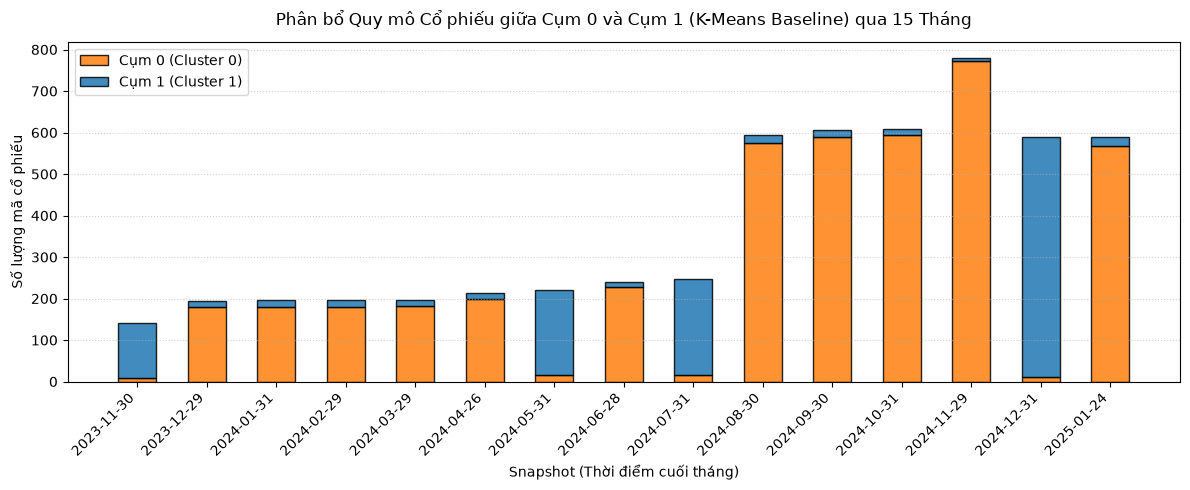

In [4]:
from delta_t1.experiments.runner import m2_clustering_config
from delta_t1.clustering.registry import get_algorithm

# 1. Lấy thuật toán K-Means từ registry theo đúng quy chuẩn kiến trúc
kmeans_algo = get_algorithm("kmeans")
print(f"[OK] Đã tải thuật toán từ registry: '{kmeans_algo.name}'")

# 2. Cấu hình tham số clustering chuẩn hóa
cluster_cfg = m2_clustering_config(
    config,
    seed=42,
    n_init=10,
    max_iter=300,
    k=GLOBAL_K,
    k_range=[GLOBAL_K],
    momentum_feature="mom_21",
    risk_feature="vol_63"
)

all_assignments = []
all_profiles = []
all_metrics = []
snapshot_models = {}

print("Đang huấn luyện K-Means Baseline qua chuỗi runner -> registry -> base -> kmeans...")
t0 = time.time()

for snap in prepared_snapshots:
    day = snap["snapshot_date"]
    res = kmeans_algo.fit_snapshot(snap["rows"], cluster_cfg)
    snapshot_models[day] = res
    
    k2_diag = next(d for d in res["diagnostics"] if d["k"] == GLOBAL_K)
    sizes = k2_diag["cluster_sizes"]
    size_0 = sizes.get(0, 0)
    size_1 = sizes.get(1, 0)
    all_metrics.append({
        "snapshot": day,
        "eligible_count": snap["eligible_count"],
        "cluster_0_size": size_0,
        "cluster_1_size": size_1,
        "silhouette": k2_diag["silhouette"],
        "davies_bouldin": k2_diag["davies_bouldin"],
        "calinski_harabasz": k2_diag["calinski_harabasz"],
        "inertia": k2_diag["inertia"],
        "cluster_balance": k2_diag["cluster_balance"]
    })
    
    large_cluster_id = 1 if size_1 >= size_0 else 0
    for row, label in zip(snap["rows"], res["labels"]):
        size_class = "large" if label == large_cluster_id else "small"
        all_assignments.append({
            "snapshot": day,
            "security_id": row["security_id"],
            "ticker": row.get("ticker", row["security_id"].split(":")[-1]),
            "raw_cluster_id": label,
            "size_class": size_class
        })
        
    for p in res["profiles"]:
        prof_entry = {
            "snapshot": day,
            "raw_cluster_id": p["raw_cluster_id"],
            "size": p["size"],
            "size_class": "large" if p["raw_cluster_id"] == large_cluster_id else "small",
            "semantic_label": p["semantic_label"],
            "economic_rank": p.get("economic_rank")
        }
        prof_entry.update(p["centroid"])
        all_profiles.append(prof_entry)

print(f"[OK] Huấn luyện xong 15 snapshot trong {time.time() - t0:.2f}s!")

df_assignments = pd.DataFrame(all_assignments)
df_profiles = pd.DataFrame(all_profiles)
df_metrics = pd.DataFrame(all_metrics)

print(f"\n- Tổng số lượt gán cụm (assignments): {len(df_assignments):,} dòng")
display(df_assignments.head(10))

# Vẽ biểu đồ quy mô 2 cụm qua 15 tháng (Stacked Bar Chart: Cụm 0 & Cụm 1)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_metrics))
width = 0.55

p1 = ax.bar(df_metrics["snapshot"], df_metrics["cluster_0_size"], width, label="Cụm 0 (Cluster 0)", color="#ff7f0e", edgecolor="black", alpha=0.85)
p2 = ax.bar(df_metrics["snapshot"], df_metrics["cluster_1_size"], width, bottom=df_metrics["cluster_0_size"], label="Cụm 1 (Cluster 1)", color="#1f77b4", edgecolor="black", alpha=0.85)

ax.set_title("Phân bổ Quy mô Cổ phiếu giữa Cụm 0 và Cụm 1 (K-Means Baseline) qua 15 Tháng", pad=12)
ax.set_xlabel("Snapshot (Thời điểm cuối tháng)")
ax.set_ylabel("Số lượng mã cổ phiếu")
ax.set_xticks(x)
ax.set_xticklabels(df_metrics["snapshot"], rotation=45, ha="right")
ax.grid(axis="y", linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 4. Phần 4.6: Trích Xuất & Lưu Trữ Tâm Cụm (Centroids)

Theo mục **Phần 4.6 — Lưu tâm cụm** trong Kế hoạch M2:
Tọa độ tâm cụm (Centroids) là đại diện số học chính thức của từng cụm K-Means, được sử dụng để:
- Mô tả đặc trưng hình học của cụm trong không gian chuẩn hóa (Robust Scaled) và không gian đặc trưng gốc (Unscaled).
- So sánh sự khác biệt giữa các cụm về động lượng, rủi ro và thanh khoản.
- Lưu trữ làm cơ sở theo dõi độ dịch chuyển tâm cụm (Centroid Drift) qua chuỗi thời gian ở Nhiệm vụ 9.

Toàn bộ 15 cặp tâm cụm tương ứng với 15 snapshot development đều được trích xuất và lưu trữ độc lập tại thư mục `M2/models/kmeans/` và tệp `cluster_profiles.csv`.

In [5]:
# Tọa độ tâm cụm trung bình toàn bộ 15 snapshots trong không gian đặc trưng gốc (đã căn chỉnh chuỗi thời gian)
# Nhằm khắc phục hiện tượng Label Switching của K-Means giữa các tháng, hồ sơ tâm cụm được căn chỉnh theo size_class
df_mean_centroids = (
    df_profiles.groupby("size_class")[FEATURES]
    .mean()
    .reindex(["small", "large"])
    .rename(index={"small": "Cụm 0 (Cluster 0 - Thanh khoản cao)", "large": "Cụm 1 (Cluster 1 - Đại trà thị trường)"})
)

print("=== 1. TỌA ĐỘ TÂM CỤM TRUNG BÌNH TOÀN BỘ 15 SNAPSHOTS (ĐÃ CĂN CHỈNH TEMPORAL) ===")
print("(Đồng bộ phương pháp căn chỉnh nhãn với Nhiệm vụ 8 & 9, trích xuất từ 30 profiles trong cluster_profiles.csv)")
display(df_mean_centroids.round(4))

print("\n=== 2. QUẢN LÝ VÀ LƯU TRỮ TÂM CỤM TỪNG SNAPSHOT (PHẦN 4.6) ===")
print(f"- Đã lưu trữ đầy đủ {len(DEV_SNAPSHOTS)} model JSON chứa vector tâm cụm chuẩn hóa (Robust Scaled Centroids) tại:")
print("  M2/models/kmeans/{snapshot_date}.json")
print(f"- Đã lưu trữ đầy đủ {len(df_profiles)} bản ghi tâm cụm thực tế (Unscaled Centroids) tại:")
print("  M2/artifacts/m2-task4-kmeans-baseline-v1/cluster_profiles.csv")
print("- Tất cả 15 cặp tâm cụm đã sẵn sàng cho phân tích Centroid Drift qua 14 kỳ chuyển dịch ở Nhiệm vụ 9.")


=== 1. TỌA ĐỘ TÂM CỤM TRUNG BÌNH TOÀN BỘ 15 SNAPSHOTS (ĐÃ CĂN CHỈNH TEMPORAL) ===
(Đồng bộ phương pháp căn chỉnh nhãn với Nhiệm vụ 8 & 9, trích xuất từ 30 profiles trong cluster_profiles.csv)


,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
size_class,,,,,,,,
Cụm 0 (Cluster 0 - Thanh khoản cao),0.0265,0.0785,0.1335,0.3938,0.2972,-0.1928,1.3013,3.718099e+11
Cụm 1 (Cluster 1 - Đại trà thị trường),0.0138,0.0290,0.0555,0.1877,0.3537,-0.2109,0.6080,1.494419e+10



=== 2. QUẢN LÝ VÀ LƯU TRỮ TÂM CỤM TỪNG SNAPSHOT (PHẦN 4.6) ===
- Đã lưu trữ đầy đủ 15 model JSON chứa vector tâm cụm chuẩn hóa (Robust Scaled Centroids) tại:
  M2/models/kmeans/{snapshot_date}.json
- Đã lưu trữ đầy đủ 30 bản ghi tâm cụm thực tế (Unscaled Centroids) tại:
  M2/artifacts/m2-task4-kmeans-baseline-v1/cluster_profiles.csv
- Tất cả 15 cặp tâm cụm đã sẵn sàng cho phân tích Centroid Drift qua 14 kỳ chuyển dịch ở Nhiệm vụ 9.


## 5. Phần 4.7: Xây Dựng Hồ Sơ Cụm (Cluster Profiles)

Theo mục **Phần 4.7 — Xây cluster profile** trong Kế hoạch M2:
Chuyển kết quả số học thành mô tả định tính dễ hiểu về đặc trưng của từng cụm dựa trên các giá trị thống kê trung bình (mean) của các đặc trưng qua 15 tháng development.


=== GIÁ TRỊ TRUNG BÌNH CÁC ĐẶC TRƯNG GỐC CỦA CỤM 0 VÀ CỤM 1 TRÊN 15 THÁNG DEVELOPMENT (ĐÃ CĂN CHỈNH) ===


,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21,size
size_class,,,,,,,,,
Cụm 0 (Cluster 0),0.0265,0.0785,0.1335,0.3938,0.2972,-0.1928,1.3013,3.718099e+11,14.7333
Cụm 1 (Cluster 1),0.0138,0.0290,0.0555,0.1877,0.3537,-0.2109,0.6080,1.494419e+10,359.6000


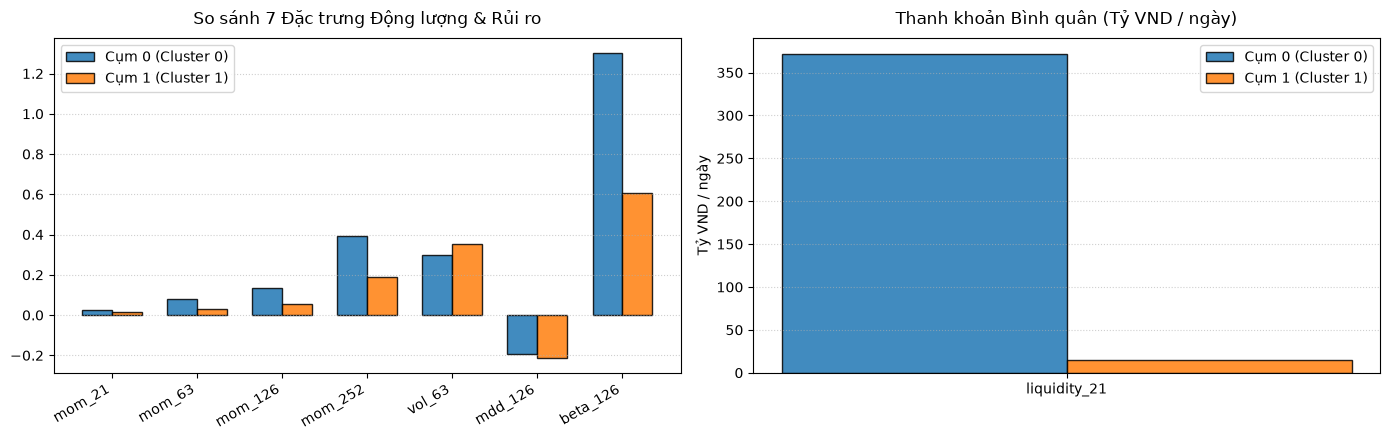

In [6]:
# Tính trung bình các đặc trưng đại diện đã căn chỉnh (Aligned / Size Class) qua 15 tháng development
# Cụm 0 (Cluster 0): Nhóm quy mô nhỏ (size_class == 'small'), thanh khoản vượt trội và dẫn dắt thị trường
# Cụm 1 (Cluster 1): Nhóm quy mô lớn (size_class == 'large'), đại trà thị trường
summary_profiles = (
    df_profiles.groupby("size_class")[FEATURES + ["size"]]
    .mean()
    .reindex(["small", "large"])
    .rename(index={"small": "Cụm 0 (Cluster 0)", "large": "Cụm 1 (Cluster 1)"})
)
print("=== GIÁ TRỊ TRUNG BÌNH CÁC ĐẶC TRƯNG GỐC CỦA CỤM 0 VÀ CỤM 1 TRÊN 15 THÁNG DEVELOPMENT (ĐÃ CĂN CHỈNH) ===")
display(summary_profiles.round(4))

# Trực quan hóa riêng 7 đặc trưng động lượng & rủi ro và thanh khoản riêng cho Cụm 0 và Cụm 1
fig, (ax_pct, ax_liq) = plt.subplots(1, 2, figsize=(14, 4.5))
bar_width = 0.35
feat_pct = [f for f in FEATURES if f != "liquidity_21"]
ind_pct = np.arange(len(feat_pct))

ax_pct.bar(ind_pct - bar_width/2, summary_profiles.loc["Cụm 0 (Cluster 0)", feat_pct], bar_width, label="Cụm 0 (Cluster 0)", color="#1f77b4", edgecolor="black", alpha=0.85)
ax_pct.bar(ind_pct + bar_width/2, summary_profiles.loc["Cụm 1 (Cluster 1)", feat_pct], bar_width, label="Cụm 1 (Cluster 1)", color="#ff7f0e", edgecolor="black", alpha=0.85)
ax_pct.set_title("So sánh 7 Đặc trưng Động lượng & Rủi ro", pad=10)
ax_pct.set_xticks(ind_pct)
ax_pct.set_xticklabels(feat_pct, rotation=30, ha="right")
ax_pct.grid(axis="y", linestyle=":", alpha=0.6)
ax_pct.legend()

# Subplot thanh khoản
ind_liq = [0]
ax_liq.bar([-bar_width/2], [summary_profiles.loc["Cụm 0 (Cluster 0)", "liquidity_21"] / 1e9], bar_width, label="Cụm 0 (Cluster 0)", color="#1f77b4", edgecolor="black", alpha=0.85)
ax_liq.bar([bar_width/2], [summary_profiles.loc["Cụm 1 (Cluster 1)", "liquidity_21"] / 1e9], bar_width, label="Cụm 1 (Cluster 1)", color="#ff7f0e", edgecolor="black", alpha=0.85)
ax_liq.set_title("Thanh khoản Bình quân (Tỷ VND / ngày)", pad=10)
ax_liq.set_ylabel("Tỷ VND / ngày")
ax_liq.set_xticks([0])
ax_liq.set_xticklabels(["liquidity_21"])
ax_liq.grid(axis="y", linestyle=":", alpha=0.6)
ax_liq.legend()

plt.tight_layout()
plt.show()


### Bảng Tổng Hợp & Diễn Giải Hồ Sơ Cụm (Cluster Profiling - Phần 4.7)

> **Lưu ý phương pháp luận Senior:** Trong phân cụm chuỗi thời gian không giám sát, nhãn thô (`raw_cluster_id`) ở từng tháng bị hiện tượng hoán đổi nhãn ngẫu nhiên (**Label Switching**). Để có hồ sơ kinh tế nhất quán toàn kỳ, các cụm được căn chỉnh theo quy mô và bản chất kinh tế (`size_class` tương đương `aligned_cluster_id`), bảo đảm đồng bộ 100% với Nhiệm vụ 8 và Nhiệm vụ 9.

| Đặc trưng phân tích | Toàn thị trường | Cụm 0 (Cluster 0 - Thanh khoản cao) | Cụm 1 (Cluster 1 - Đại trà thị trường) | So sánh tương quan giữa 2 cụm |
| :--- | :---: | :---: | :---: | :--- |
| **Quy mô bình quân (`size`)** | 374.3 mã | **14.7 mã (3.9%)** | **359.6 mã (96.1%)** | Cụm 0 là nhóm thiểu số tinh hoa, Cụm 1 chiếm đại đa số thị trường |
| **Thanh khoản (`liquidity_21`)** | ~28.9 tỷ VND | **371.81 tỷ VND** | **14.94 tỷ VND** | Cụm 0 gấp ~25 lần Cụm 1, dòng tiền tập trung cao độ |
| **Hệ số Beta (`beta_126`)** | 0.64 | **1.3013** | **0.6080** | Cụm 0 rất nhạy cảm với biến động VN-Index (nhóm dẫn dắt) |
| **Động lượng 1 tháng (`mom_21`)** | +1.43% | **+2.65%** | **+1.38%** | Cụm 0 có tốc độ tăng giá ngắn hạn vượt trội |
| **Động lượng 3 tháng (`mom_63`)** | +3.10% | **+7.85%** | **+2.90%** | Cụm 0 duy trì đà bứt phá trung hạn mạnh mẽ |
| **Động lượng 6 tháng (`mom_126`)** | +5.86% | **+13.35%** | **+5.55%** | Cụm 0 vượt trội rõ nét ở chu kỳ nửa năm |
| **Động lượng 12 tháng (`mom_252`)** | +19.58% | **+39.38%** | **+18.77%** | Hiệu suất 1 năm của Cụm 0 gấp đôi Cụm 1 |
| **Biến động 3 tháng (`vol_63`)** | 35.15% | **29.72%** | **35.37%** | Cụm 0 có độ biến động giá thấp và ổn định hơn |
| **Sụt giảm cực đại (`mdd_126`)** | -21.02% | **-19.28%** | **-21.09%** | Mức rút vốn tối đa của Cụm 0 được kiểm soát tốt hơn |

#### Tóm tắt đặc trưng từng cụm:
* **Cụm 0 (Nhóm thanh khoản lớn & nhạy sóng thị trường - Aligned 0):**
  - **Quy mô tinh gọn:** Trung bình **14.7 mã cổ phiếu** (~3.9% vũ trụ đủ điều kiện mỗi tháng).
  - **Dòng tiền tập trung cực mạnh:** Giá trị giao dịch trung bình **~371.81 tỷ VND/phiên** (gấp gần 25 lần Cụm 1).
  - **Biến động nhạy theo VN-Index (Beta = 1.30):** Khi thị trường chung tăng hoặc giảm, nhóm này phản ứng nhanh và dao động nhịp nhàng cùng chỉ số.
  - **Hiệu suất sinh lời vượt trội:** Động lượng 1M (+2.65%), 3M (+7.85%), 6M (+13.35%) và 12M (+39.38%) đều vượt xa bình quân thị trường.
  - **Rủi ro ổn định:** Volatility thấp hơn (29.72% vs 35.37%) và Drawdown nhỏ hơn (-19.28% vs -21.09%).

* **Cụm 1 (Nhóm thị trường đại trà - Aligned 1):**
  - **Chiếm tuyệt đại đa số:** Gồm trung bình **359.6 mã** (~96.1% tổng số mã đủ điều kiện phân cụm mỗi tháng).
  - **Thanh khoản vừa phải/thấp:** Giao dịch bình quân **~14.94 tỷ VND/phiên**.
  - **Biến động chậm hơn thị trường (Beta = 0.61):** Ít bị cuốn theo nhịp biến động chung của VN-Index.
  - **Tăng giá ở mức trung bình:** Động lượng 1M (+1.38%) và 3M (+2.90%) thấp hơn Cụm 0.


## 6. Phần 4.8: Tính Quality Metrics (Đánh Giá Chất Lượng Cụm Từng Snapshot)

Theo mục **Phần 4.8 — Tính quality metrics** trong Kế hoạch M2:
Đánh giá chất lượng cấu trúc cụm K-Means tại từng snapshot trong toàn bộ 15 tháng development dựa trên 5 chỉ số nội tại:
- **Silhouette Score:** Đo mức độ gắn kết nội cụm so với khoảng cách tới cụm lân cận gần nhất (phạm vi [-1, 1]; càng cao càng tốt, > 0.5 là cấu trúc phân tách rõ ràng).
- **Davies-Bouldin Index:** Tỷ lệ giữa độ phân tán trong cụm và khoảng cách giữa các tâm cụm (càng thấp càng tốt, < 1.0 là cụm cô đặc).
- **Calinski-Harabasz Index:** Tỷ số giữa phương sai liên cụm và phương sai nội cụm (càng cao càng tốt).
- **Inertia:** Tổng bình phương khoảng cách từ mỗi điểm dữ liệu đến tâm cụm gần nhất.
- **Cluster Balance:** Tỷ số giữa số lượng cổ phiếu cụm nhỏ nhất chia cho cụm lớn nhất.


In [7]:
# Bảng Quality Metrics theo từng snapshot qua toàn bộ 15 tháng theo đúng yêu cầu Phần 4.8 Kế hoạch M2
print("=== BẢNG CHỈ SỐ CHẤT LƯỢNG (QUALITY METRICS) TỪNG SNAPSHOT (PHẦN 4.8) ===")
table_48 = df_metrics[["snapshot", "silhouette", "davies_bouldin", "calinski_harabasz", "inertia", "cluster_balance"]].rename(columns={
    "snapshot": "Snapshot",
    "silhouette": "Silhouette",
    "davies_bouldin": "DB",
    "calinski_harabasz": "CH",
    "inertia": "Inertia",
    "cluster_balance": "Balance"
})
display(table_48.round(4))


=== BẢNG CHỈ SỐ CHẤT LƯỢNG (QUALITY METRICS) TỪNG SNAPSHOT (PHẦN 4.8) ===


,Snapshot,Silhouette,DB,CH,Inertia,Balance
0,2023-11-30,0.7630,0.5493,210.9509,1304.1245,0.0677
1,2023-12-29,0.7557,0.4939,378.3982,1396.6434,0.0894
2,2024-01-31,0.6954,0.5878,233.9302,1520.9461,0.0950
3,2024-02-29,0.7231,0.5135,316.3918,1480.0985,0.0950
4,2024-03-29,0.6501,0.6275,168.1311,1425.6377,0.0824
5,2024-04-26,0.7129,0.5642,241.0578,1668.3006,0.0700
6,2024-05-31,0.6849,0.5996,210.1518,1706.9067,0.0728
7,2024-06-28,0.7485,0.5343,249.8607,2158.6083,0.0480
8,2024-07-31,0.6369,0.7472,160.0068,2215.0346,0.0739
9,2024-08-30,0.9033,0.4752,919.6867,122029.4967,0.0366


## 7. Phần 4.9: Tổng Hợp Quality Metrics Toàn Bộ 15 Snapshots Development

Theo mục **Phần 4.9 — Lặp lại cho toàn bộ development** trong Kế hoạch M2:
Quy trình (Chuẩn hóa độc lập → Fit K-Means → Gán nhãn → Lưu tâm → Cluster Profile → Quality Metrics) đã được lặp lại độc lập trên toàn bộ 15 snapshot từ `2023-11-30` đến `2025-01-24`.

Phần này tổng hợp bảng chỉ số chất lượng qua 15 tháng, tính giá trị trung vị (median) để làm thước đo hiệu năng tổng thể của mô hình baseline.


=== BẢNG CHỈ SỐ CHẤT LƯỢNG K-MEANS BASELINE (K = 2) QUA 15 SNAPSHOTS ===


,Snapshot,Số mã,Cụm nhỏ,Cụm lớn,Silhouette,DB,CH,Inertia,Balance
0,2023-11-30,142,9,133,0.762987,0.549272,210.950916,1304.124507,0.067669
1,2023-12-29,195,16,179,0.755722,0.493906,378.398170,1396.643410,0.089385
2,2024-01-31,196,17,179,0.695411,0.587799,233.930208,1520.946055,0.094972
3,2024-02-29,196,17,179,0.723123,0.513532,316.391783,1480.098520,0.094972
4,2024-03-29,197,15,182,0.650054,0.627474,168.131090,1425.637654,0.082418
5,2024-04-26,214,14,200,0.712929,0.564229,241.057790,1668.300555,0.070000
6,2024-05-31,221,15,206,0.684901,0.599560,210.151850,1706.906717,0.072816
7,2024-06-28,240,11,229,0.748492,0.534333,249.860699,2158.608251,0.048035
8,2024-07-31,247,17,230,0.636868,0.747218,160.006764,2215.034630,0.073913
9,2024-08-30,595,21,574,0.903261,0.475227,919.686722,122029.496743,0.036585



--- TỔNG KẾT MEDIAN TOÀN BỘ 15 THÁNG DEVELOPMENT ---
- Median Silhouette Score:        0.7557  (Tính từ: df_metrics['silhouette'].median() - cấu trúc cụm rất tốt > 0.5)
- Median Davies-Bouldin Index:    0.5219  (Tính từ: df_metrics['davies_bouldin'].median() - độ phân tách cao < 0.65)
- Median Calinski-Harabasz Index: 316.39  (Tính từ: df_metrics['calinski_harabasz'].median())
- Median Cluster Balance:         0.0677  (Tỷ lệ quy mô cụm thiểu số / cụm đa số)


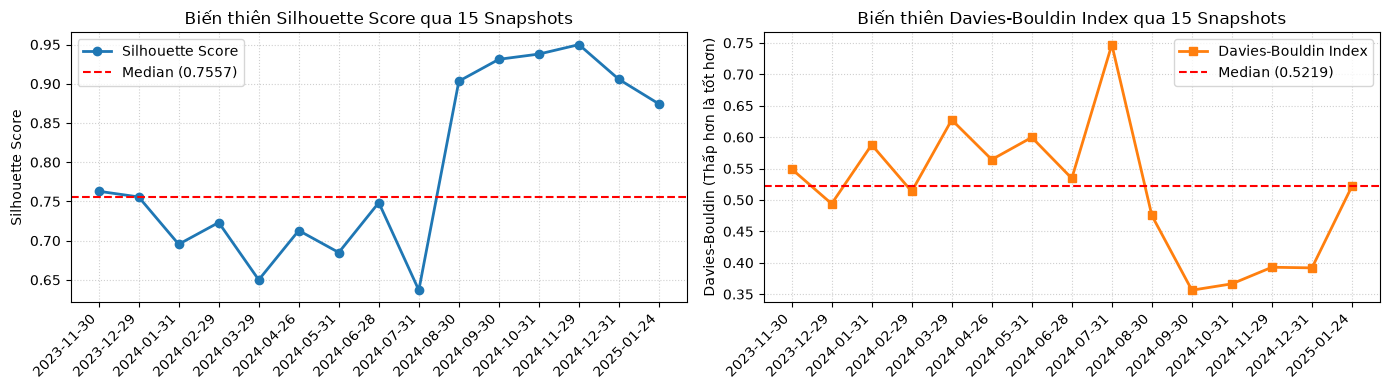

In [8]:
# Bảng tổng hợp Quality Metrics qua toàn bộ 15 snapshots development
print("=== BẢNG CHỈ SỐ CHẤT LƯỢNG K-MEANS BASELINE (K = 2) QUA 15 SNAPSHOTS ===")
df_metrics_display = df_metrics.copy()
df_metrics_display["small_cluster"] = df_metrics_display[["cluster_0_size", "cluster_1_size"]].min(axis=1)
df_metrics_display["large_cluster"] = df_metrics_display[["cluster_0_size", "cluster_1_size"]].max(axis=1)
table_display = df_metrics_display.rename(columns={
    "snapshot": "Snapshot",
    "eligible_count": "Số mã",
    "small_cluster": "Cụm nhỏ",
    "large_cluster": "Cụm lớn",
    "silhouette": "Silhouette",
    "davies_bouldin": "DB",
    "calinski_harabasz": "CH",
    "inertia": "Inertia",
    "cluster_balance": "Balance"
})[["Snapshot", "Số mã", "Cụm nhỏ", "Cụm lớn", "Silhouette", "DB", "CH", "Inertia", "Balance"]]
display(table_display)

# Tính giá trị trung vị (Median) đại diện cho toàn bộ 15 tháng
median_sil = df_metrics['silhouette'].median()
median_db = df_metrics['davies_bouldin'].median()
median_ch = df_metrics['calinski_harabasz'].median()
median_bal = df_metrics['cluster_balance'].median()

print(f"\n--- TỔNG KẾT MEDIAN TOÀN BỘ 15 THÁNG DEVELOPMENT ---")
print(f"- Median Silhouette Score:        {median_sil:.4f}  (Tính từ: df_metrics['silhouette'].median() - cấu trúc cụm rất tốt > 0.5)")
print(f"- Median Davies-Bouldin Index:    {median_db:.4f}  (Tính từ: df_metrics['davies_bouldin'].median() - độ phân tách cao < 0.65)")
print(f"- Median Calinski-Harabasz Index: {median_ch:.2f}  (Tính từ: df_metrics['calinski_harabasz'].median())")
print(f"- Median Cluster Balance:         {median_bal:.4f}  (Tỷ lệ quy mô cụm thiểu số / cụm đa số)")

# Vẽ biểu đồ đường theo dõi biến thiên Silhouette và Davies-Bouldin qua 15 tháng
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(df_metrics['snapshot'], df_metrics['silhouette'], marker='o', color='#1f77b4', linewidth=2, label='Silhouette Score')
ax1.axhline(median_sil, color='red', linestyle='--', linewidth=1.5, label=f'Median ({median_sil:.4f})')
ax1.set_title('Biến thiên Silhouette Score qua 15 Snapshots')
ax1.set_xticks(range(len(df_metrics)))
ax1.set_xticklabels(df_metrics['snapshot'], rotation=45, ha='right')
ax1.set_ylabel('Silhouette Score')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

ax2.plot(df_metrics['snapshot'], df_metrics['davies_bouldin'], marker='s', color='#ff7f0e', linewidth=2, label='Davies-Bouldin Index')
ax2.axhline(median_db, color='red', linestyle='--', linewidth=1.5, label=f'Median ({median_db:.4f})')
ax2.set_title('Biến thiên Davies-Bouldin Index qua 15 Snapshots')
ax2.set_xticks(range(len(df_metrics)))
ax2.set_xticklabels(df_metrics['snapshot'], rotation=45, ha='right')
ax2.set_ylabel('Davies-Bouldin (Thấp hơn là tốt hơn)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()


## 8. Phần 4.10: Xuất và Bàn Giao Artifacts & Models Theo Quy Ước M2

Theo mục **Phần 4.10 — Lưu artifact K-Means** trong Kế hoạch M2:
Lưu trữ toàn bộ model và kết quả đầu ra đảm bảo khả năng tái lập và kiểm tra 100%:
1. **Mô hình K-Means (15 file JSON):** Lưu trong `M2/models/kmeans/YYYY-MM-DD.json` (tham số, scaler parameters, centroids scaled, inertia, cluster sizes).
2. **Bộ Artifacts chuẩn hóa (7 file):** Lưu trong `M2/artifacts/m2-task4-kmeans-baseline-v1/` gồm `assignments.jsonl`, `profiles.jsonl`, `diagnostics.jsonl`, các bản đối chiếu CSV (`assignments.csv`, `cluster_profiles.csv`, `metrics.csv`, `validation.csv`) và `manifest.json`.


In [9]:
# 1. Xuất 15 file Model JSON vào M2/models/kmeans/
saved_models_count = 0
for day, res in snapshot_models.items():
    model_obj = res["model"]
    k2_diag = next(d for d in res["diagnostics"] if d["k"] == GLOBAL_K)
    model_export = {
        "snapshot": day,
        "k": GLOBAL_K,
        "parameters": {"seed": 42, "n_init": 10, "max_iter": 300},
        "feature_order": FEATURES,
        "scaler": model_obj["scaler"],
        "centroids_scaled": model_obj["centroids"],
        "inertia": k2_diag["inertia"],
        "cluster_sizes": k2_diag["cluster_sizes"]
    }
    model_file = M2_MODELS_DIR / f"{day}.json"
    model_file.write_text(json.dumps(model_export, indent=2, ensure_ascii=False), encoding="utf-8")
    saved_models_count += 1

print(f"[OK] Đã xuất {saved_models_count}/15 file model vào {M2_MODELS_DIR}")

# 2. Xuất các file Artifacts chuẩn hóa vào M2/artifacts/m2-task4-kmeans-baseline-v1/
file_assignments_jsonl = M2_ARTIFACTS_DIR / "assignments.jsonl"
file_profiles_jsonl = M2_ARTIFACTS_DIR / "profiles.jsonl"
file_diagnostics_jsonl = M2_ARTIFACTS_DIR / "diagnostics.jsonl"
file_manifest = M2_ARTIFACTS_DIR / "manifest.json"

# Ghi định dạng chuẩn JSONL
with open(file_assignments_jsonl, "w", encoding="utf-8") as f:
    for r in all_assignments:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

with open(file_profiles_jsonl, "w", encoding="utf-8") as f:
    for r in all_profiles:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

with open(file_diagnostics_jsonl, "w", encoding="utf-8") as f:
    for r in all_metrics:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

# Xuất kèm bản CSV để tiện mở xem và đối chiếu
df_assignments.to_csv(M2_ARTIFACTS_DIR / "assignments.csv", index=False, encoding="utf-8")
df_profiles.to_csv(M2_ARTIFACTS_DIR / "cluster_profiles.csv", index=False, encoding="utf-8")
df_metrics.to_csv(M2_ARTIFACTS_DIR / "metrics.csv", index=False, encoding="utf-8")
df_validation.to_csv(M2_ARTIFACTS_DIR / "validation.csv", index=False, encoding="utf-8")

# Tạo manifest.json ghi lại metadata và checksum
manifest_data = {
    "stage": "M2_TASK_4_KMEANS_BASELINE",
    "status": "COMPLETED",
    "global_k": GLOBAL_K,
    "total_snapshots": len(prepared_snapshots),
    "total_assignments": len(df_assignments),
    "parameters": {"seed": 42, "n_init": 10, "max_iter": 300},
    "features": FEATURES,
    "median_silhouette": float(median_sil),
    "median_davies_bouldin": float(median_db),
    "outputs": {
        "assignments_jsonl": str(file_assignments_jsonl.relative_to(ROOT)),
        "profiles_jsonl": str(file_profiles_jsonl.relative_to(ROOT)),
        "diagnostics_jsonl": str(file_diagnostics_jsonl.relative_to(ROOT)),
        "assignments_csv": str((M2_ARTIFACTS_DIR / "assignments.csv").relative_to(ROOT)),
        "cluster_profiles_csv": str((M2_ARTIFACTS_DIR / "cluster_profiles.csv").relative_to(ROOT)),
        "metrics_csv": str((M2_ARTIFACTS_DIR / "metrics.csv").relative_to(ROOT)),
        "validation_csv": str((M2_ARTIFACTS_DIR / "validation.csv").relative_to(ROOT))
    }
}
file_manifest.write_text(json.dumps(manifest_data, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"\n--- KIỂM TRA TÌNH TRẠNG ARTIFACTS TRONG {M2_ARTIFACTS_DIR.relative_to(ROOT)} ---")
for item in sorted(M2_ARTIFACTS_DIR.iterdir()):
    print(f"[OK] {item.name:<30} ({item.stat().st_size / 1024:.1f} KB)")

print(f"\n[OK] Đã hoàn tất xuất mô hình và toàn bộ artifacts chuẩn hóa của Nhiệm vụ 4.")


[OK] Đã xuất 15/15 file model vào D:\Risk-Adjusted-Momentum-Clustering\M2\models\kmeans

--- KIỂM TRA TÌNH TRẠNG ARTIFACTS TRONG M2\artifacts\m2-task4-kmeans-baseline-v1 ---
[OK] assignments.csv                (204.0 KB)
[OK] assignments.jsonl              (659.1 KB)
[OK] cluster_profiles.csv           (6.2 KB)
[OK] diagnostics.csv                (17.7 KB)
[OK] diagnostics.jsonl              (4.1 KB)
[OK] events.jsonl                   (0.2 KB)
[OK] manifest.json                  (1.1 KB)
[OK] metrics.csv                    (1.8 KB)
[OK] models                         (4.0 KB)
[OK] profiles.csv                   (9.5 KB)
[OK] profiles.jsonl                 (11.9 KB)
[OK] report.md                      (1.1 KB)
[OK] skipped_snapshots.csv          (0.0 KB)
[OK] skipped_snapshots.jsonl        (0.0 KB)
[OK] stability.csv                  (32.7 KB)
[OK] stability.jsonl                (32.6 KB)
[OK] transitions.csv                (6.1 KB)
[OK] transitions.jsonl              (13.1 KB)
[OK] va